In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models  import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN



In [93]:
t=np.arange(0,2000)
X=np.sin(0.01*t)

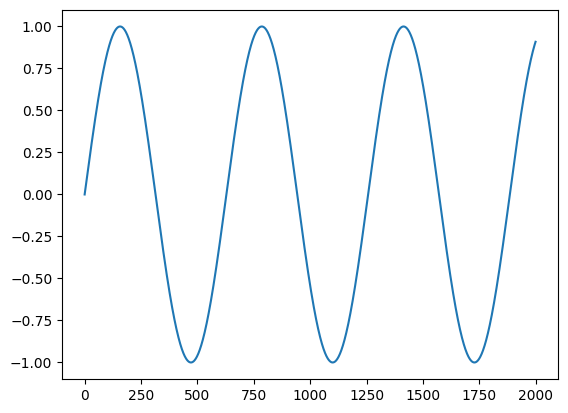

In [94]:
plt.plot(X)

In [95]:
X

array([0.        , 0.00999983, 0.01999867, ..., 0.90029383, 0.90460157,
       0.90881885], shape=(2000,))

In [96]:
X_train,X_test=X[:1500],X[1500:]

In [97]:
model=Sequential()
model.add(SimpleRNN(units=64,activation="relu"))
model.add(Dense(1))

In [98]:
model.compile(loss='mean_absolute_error', optimizer='adam')

In [99]:
X_train2,Y_train2=[],[]
for i in range(len(X_train)-15):
    d=i+15
    X_train2.append(X_train[i:d,])
    Y_train2.append(X_train[d])

In [100]:
X_test2,Y_test2=[],[]
for i in range(len(X_test)-15):
    d=i+15
    X_test2.append(X_test[i:d,])
    Y_test2.append(X_test[d])

In [101]:
X_train2=np.array(X_train2)
X_test2=np.array(X_test2)

In [102]:
X_train2[0]

array([0.        , 0.00999983, 0.01999867, 0.0299955 , 0.03998933,
       0.04997917, 0.05996401, 0.06994285, 0.07991469, 0.08987855,
       0.09983342, 0.1097783 , 0.11971221, 0.12963414, 0.13954311])

In [103]:
Y_train2[2]

np.float64(0.16918234906699603)

In [104]:
X_train2=np.reshape(X_train2,(X_train2.shape[0],X_train2.shape[1],1))
X_test2=np.reshape(X_test2,(X_test2.shape[0],X_test2.shape[1],1))

In [105]:
X_train2.shape

(1485, 15, 1)

In [106]:
X_train2[0]

array([[0.        ],
       [0.00999983],
       [0.01999867],
       [0.0299955 ],
       [0.03998933],
       [0.04997917],
       [0.05996401],
       [0.06994285],
       [0.07991469],
       [0.08987855],
       [0.09983342],
       [0.1097783 ],
       [0.11971221],
       [0.12963414],
       [0.13954311]])

In [107]:
Y_train2=np.array(Y_train2)
X_train2=np.array(X_train2)

In [108]:
model.fit(X_train2,Y_train2,epochs=100,batch_size=20)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1579
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0097
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0091
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0083
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0073
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0074
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0057
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0061
Epoch 9/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0065
Epoch 10/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0070
Epoch 11/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0064
Epoch 12/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0047
Epoch 13/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0056
Epoch 14/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0044
Epoch 15/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0048
Epoc

In [109]:
model.evaluate(X_train2,Y_train2)


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0033


0.0033337362110614777

In [110]:
X_train2_predic=model.predict(X_train2)
X_test2_predic=model.predict(X_test2)
XFINAL=np.concatenate([X_train2_predic,X_test2_predic],axis=0)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


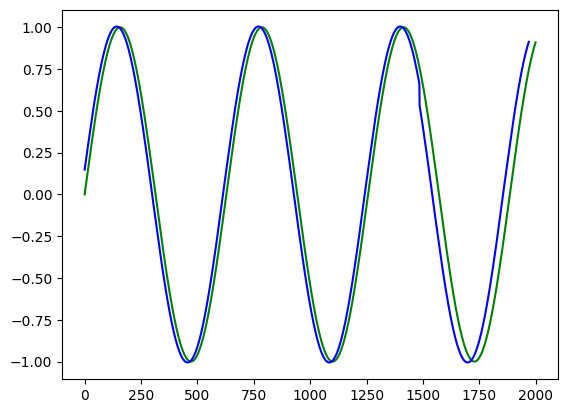

In [111]:
plt.plot(X,color='green')
plt.plot(XFINAL,color='blue')